In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.script.variable_profiling import eda_per_table_printing_results
from default_risk.script.variable_profiling import eda_per_table_persisting_result_html
from default_risk.script.variable_profiling import create_files_nulls_per_colmun
import default_risk.config as cfg


bureau_balance_df= pd.read_csv(cfg.BUREAU_BALANCE)

with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)

In [ ]:
#create the files por data data dictionary
create_files_nulls_per_colmun(bureau_balance_df,"bureu_balance")

In [ ]:
#run the screening script on bureau_balance
eda_per_table_printing_results(bureau_balance_df, schema, "bureau_balance",False)

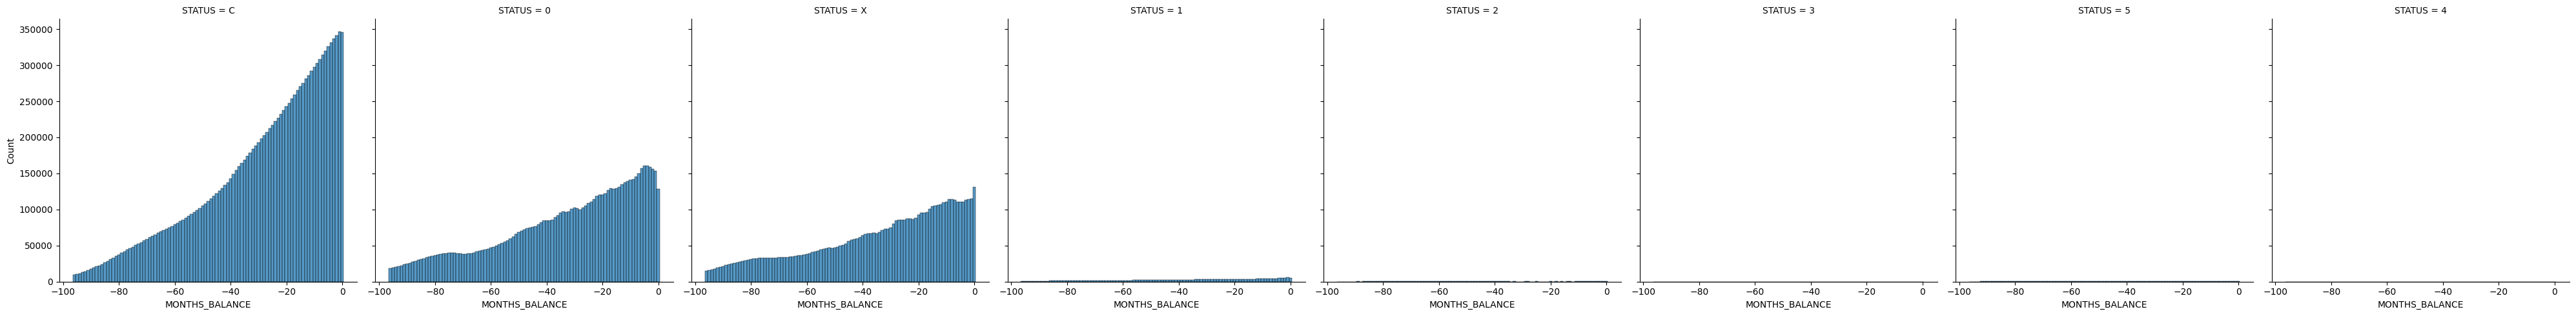

In [2]:
sns.displot(data=bureau_balance_df,bins=1,discrete=True,kind="hist", x="MONTHS_BALANCE",col="STATUS")

In [3]:
#there is cases where the loan is mark "C" (Closed) and reactivated again? the status closed is reversible?
grouped_closed_in_first_month= bureau_balance_df.groupby("SK_ID_BUREAU").filter(lambda g: ((g[g["MONTHS_BALANCE"] == -1])["STATUS"] == "C").sum() > 0)
reverted= grouped_closed_in_first_month.groupby("SK_ID_BUREAU").filter(lambda g: ((g[g["MONTHS_BALANCE"] < -1])["STATUS"] == "-1").sum()> 0)
reverted.head()
#evidence of there is no cases where that happends

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
